In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["NO_ALBUMENTATIONS_UPDATE"] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [4]:
import keras
print(keras.__version__)

3.8.0


In [5]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [6]:
import cv2
import math
import time
import shutil 
import random
import itertools
import numpy as np
import pandas as pd 
from glob import glob
import albumentations as A
from tensorflow.keras import ops
from tensorflow import keras
from functools import partial
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

In [7]:
# tf.keras.saving.get_custom_objects().clear()
# tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))
tf.config.optimizer.set_jit(False) ## enabling XLA

In [8]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Pretraining

In [9]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60     
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [10]:
tempfolder="temp_HAM10000"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

In [11]:
data_root="Datasets/1.HAM10000/metaaug/siamese/fold1/"
output_path="./"+tempfolder+"/"

In [12]:
train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [13]:
classes=sorted(os.listdir(train_dir))
print(classes)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [14]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  7
num_train_images :  619
num_test_images :  150


In [15]:
EPOCHS=100
IMG_SIZE=224
BATCH_SIZE=64
LEARNING_RATE=1e-4
dropout_rate=0.3
BUFFER_SIZE=10000
AUTO=tf.data.AUTOTUNE

In [16]:
BUFFER_SIZE=num_train_images
AUTO=tf.data.AUTOTUNE
TRAIN_STEPS_PER_EPOCH=math.ceil(num_train_images/BATCH_SIZE)
TEST_STEPS_PER_EPOCH=math.ceil(num_test_images/BATCH_SIZE)

In [17]:
ModelCheckPoint=tf.keras.callbacks.ModelCheckpoint(
    filepath=output_path+'EfficientNetB0-{epoch:03d}-{val_accuracy:.4f}.weights.h5',
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [18]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="RandomChance")
class RandomChance(tf.keras.layers.Layer):
    def __init__(self, layer, probability, **kwargs):
        super(RandomChance, self).__init__(**kwargs)
        self.layer = layer
        self.probability = probability

    def call(self, inputs, training=True):
        apply_layer = tf.random.uniform([]) < self.probability
        outputs = tf.cond(pred=tf.logical_and(apply_layer, training),
                          true_fn=lambda: self.layer(inputs), false_fn=lambda: inputs,)
        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({"layer": tf.keras.layers.serialize(self.layer),
                        "probability": self.probability,})
        return config

In [19]:
random_aug = tf.keras.Sequential([
    RandomChance(tf.keras.layers.RandomFlip(mode='horizontal_and_vertical'), 0.1),
    RandomChance(tf.keras.layers.RandomRotation(0.1, fill_mode='nearest'), 0.1),
    RandomChance(tf.keras.layers.RandomTranslation(0.1, 0.1, fill_mode='nearest'), 0.1),
    RandomChance(tf.keras.layers.RandomZoom(0.1, fill_mode='nearest'), 0.1),
])

In [20]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")    
    image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE))
    return image, label

In [21]:
file_names_train=glob(train_dir + '/*/*')
random.shuffle(file_names_train)    
lbls_train=[classes.index(name.split('/')[-2]) for name in file_names_train]
lbls_train_one_hot = tf.one_hot(lbls_train, depth=num_classes)
train_dataset=tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train_one_hot))

In [22]:
train_dataset=(
    train_dataset
    .shuffle(buffer_size=BUFFER_SIZE)
    .map(parse_image, num_parallel_calls=AUTO) 
    .map(lambda x, y: (random_aug(x, training=True), y), num_parallel_calls=AUTO)    
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTO)
)

In [23]:
file_names_test=glob(test_dir + '/*/*')    
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
lbls_test_one_hot = tf.one_hot(lbls_test, depth=num_classes)
test_dataset=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test_one_hot))

In [24]:
test_dataset=(
    test_dataset    
    .map(parse_image, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTO)
)

In [25]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6]), array([ 43,  60, 103,  19, 104, 268,  22]))


In [26]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {0: 2.0565, 1: 1.4738, 2: 0.8585, 3: 4.6541, 4: 0.8503, 5: 0.33, 6: 4.0195}


In [27]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=False

In [28]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [29]:
x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x) 
embedding_network = tf.keras.Model(base_model.input, output, name="Embedding_EfficientNetB0")

In [30]:
i=1
j=len(embedding_network.layers)
for x in embedding_network.layers:
    print(i, j, x.name, x.output.shape, x.trainable)
    i=i+1
    j=j-1

1 249 input_layer_1 (None, 224, 224, 3) False
2 248 rescaling (None, 224, 224, 3) False
3 247 normalization (None, 224, 224, 3) False
4 246 rescaling_1 (None, 224, 224, 3) False
5 245 stem_conv_pad (None, 225, 225, 3) False
6 244 stem_conv (None, 112, 112, 32) False
7 243 stem_bn (None, 112, 112, 32) False
8 242 stem_activation (None, 112, 112, 32) False
9 241 block1a_dwconv (None, 112, 112, 32) False
10 240 block1a_bn (None, 112, 112, 32) False
11 239 block1a_activation (None, 112, 112, 32) False
12 238 block1a_se_squeeze (None, 32) False
13 237 block1a_se_reshape (None, 1, 1, 32) False
14 236 block1a_se_reduce (None, 1, 1, 8) False
15 235 block1a_se_expand (None, 1, 1, 32) False
16 234 block1a_se_excite (None, 112, 112, 32) False
17 233 block1a_project_conv (None, 112, 112, 16) False
18 232 block1a_project_bn (None, 112, 112, 16) False
19 231 block2a_expand_conv (None, 112, 112, 96) False
20 230 block2a_expand_bn (None, 112, 112, 96) False
21 229 block2a_expand_activation (None, 112,

In [31]:
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in embedding_network.trainable_weights]))
non_trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in embedding_network.non_trainable_weights]))
total_count = trainable_count + non_trainable_count

print('Total params: {:,}'.format(total_count))
print('Trainable params: {:,}'.format(trainable_count))
print('Non-trainable params: {:,}'.format(non_trainable_count))

Total params: 4,779,709
Trainable params: 726,298
Non-trainable params: 4,053,411


In [32]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

In [33]:
flops = get_flops(embedding_network)
macs = flops / 2


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [34]:
print(macs/10 ** 9)

0.401186667


In [35]:
print(flops/10 ** 9)

0.802373334


In [36]:
regularizer=tf.keras.regularizers.l2(1e-5)
for layer in embedding_network.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

# Phase 1

In [37]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)  
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2, label_smoothing=0.05)

embedding_network.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [38]:
%%time
t1=time.time()
history = embedding_network.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=classWeight_dict,
    # callbacks=[ModelCheckPoint] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/100
 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2104 - loss: 0.6930

I0000 00:00:1741020748.562180 2566913 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.2079 - loss: 0.6632 - val_accuracy: 0.3533 - val_loss: 0.3413
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.1695 - loss: 0.6752 - val_accuracy: 0.4400 - val_loss: 0.3307
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.2543 - loss: 0.5225 - val_accuracy: 0.4867 - val_loss: 0.3208
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.2225 - loss: 0.5023 - val_accuracy: 0.4933 - val_loss: 0.3119
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.2521 - loss: 0.4592 - val_accuracy: 0.4867 - val_loss: 0.3046
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.3116 - loss: 0.4244 - val_accuracy: 0.4533 - val_loss: 0.2999
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.3273 - loss: 0.3898 - val_accuracy: 0.4467 - val_loss: 0.2950
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.3369 - loss: 0.4286 - val_accuracy: 0.4667 -

In [39]:
test_loss, test_accuracy_by_evaluate = embedding_network.evaluate(test_dataset)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5460 - loss: 0.2617


In [40]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [41]:
print(test_accuracy_by_evaluate_rounded)

53.33


In [42]:
model_name_1 = "embedding_network_phase1_weights.keras"
embedding_network.save(output_path+model_name_1)

# Phase 2

In [43]:
embedding_network = tf.keras.models.load_model(output_path+model_name_1, 
    custom_objects={'SpatialAttention': SpatialAttention, 'RandomChance': RandomChance})

In [44]:
layer_index = [i for i, layer in enumerate(embedding_network.layers) if layer.name == "block4a_expand_conv"][0]
for layer in embedding_network.layers[:layer_index]:
    layer.trainable = False
    
for layer in embedding_network.layers[layer_index:]:
    layer.trainable = True

In [45]:
i=1
j=len(embedding_network.layers)
for x in embedding_network.layers:
    print(i, j, x.name, x.output.shape, x.trainable)
    i=i+1
    j=j-1

1 249 input_layer_1 (None, 224, 224, 3) False
2 248 rescaling (None, 224, 224, 3) False
3 247 normalization (None, 224, 224, 3) False
4 246 rescaling_1 (None, 224, 224, 3) False
5 245 stem_conv_pad (None, 225, 225, 3) False
6 244 stem_conv (None, 112, 112, 32) False
7 243 stem_bn (None, 112, 112, 32) False
8 242 stem_activation (None, 112, 112, 32) False
9 241 block1a_dwconv (None, 112, 112, 32) False
10 240 block1a_bn (None, 112, 112, 32) False
11 239 block1a_activation (None, 112, 112, 32) False
12 238 block1a_se_squeeze (None, 32) False
13 237 block1a_se_reshape (None, 1, 1, 32) False
14 236 block1a_se_reduce (None, 1, 1, 8) False
15 235 block1a_se_expand (None, 1, 1, 32) False
16 234 block1a_se_excite (None, 112, 112, 32) False
17 233 block1a_project_conv (None, 112, 112, 16) False
18 232 block1a_project_bn (None, 112, 112, 16) False
19 231 block2a_expand_conv (None, 112, 112, 96) False
20 230 block2a_expand_bn (None, 112, 112, 96) False
21 229 block2a_expand_activation (None, 112,

In [46]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)  
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2, label_smoothing=0.05)

embedding_network.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [47]:
%%time
t1=time.time()
history = embedding_network.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=classWeight_dict,
    # callbacks=[ModelCheckPoint] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 120s 6s/step - accuracy: 0.2901 - loss: 0.6980 - val_accuracy: 0.5667 - val_loss: 0.5126
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.3758 - loss: 0.6385 - val_accuracy: 0.5533 - val_loss: 0.5095
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.4112 - loss: 0.5816 - val_accuracy: 0.5667 - val_loss: 0.5084
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.4111 - loss: 0.5664 - val_accuracy: 0.5600 - val_loss: 0.5107
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.5104 - loss: 0.4954 - val_accuracy: 0.5667 - val_loss: 0.5129
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.5115 - loss: 0.4841 - val_accuracy: 0.5533 - val_loss: 0.5124
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.5247 - loss: 0.4904 - val_accuracy: 0.5533 - val_loss: 0.5139
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.5658 - loss: 0.4704 - val_accur

In [48]:
test_loss, test_accuracy_by_evaluate = embedding_network.evaluate(test_dataset)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6550 - loss: 0.4714 


In [49]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [50]:
print(test_accuracy_by_evaluate_rounded)

67.33


In [51]:
model_name_2 = "embedding_network_phase2_weights.keras"
embedding_network.save(output_path+model_name_2)

# Load Siamese Data

In [52]:
embedding_network = tf.keras.models.load_model(output_path+model_name_2, 
    custom_objects={'SpatialAttention': SpatialAttention, 'RandomChance': RandomChance})

In [53]:
EPOCHS=200
IMG_SIZE=224
BATCH_SIZE=256
LEARNING_RATE=1e-4
dropout_rate=0.3
BUFFER_SIZE=10000
AUTO=tf.data.AUTOTUNE

In [54]:
end = '_HAM10000_Siamese'
destination='Results/siamese/1.HAM10000/'

train_csv_file="fold1_train.csv" 
test_csv_file="fold1_test.csv" 

output_filename_train_genuine = "ham10000_siamese_train_genuine_pairs.csv"
output_filename_train_imposter = "ham10000_siamese_train_imposter_pairs.csv"  

output_filename_test_genuine = "ham10000_siamese_test_genuine_pairs.csv"
output_filename_test_imposter = "ham10000_siamese_test_imposter_pairs.csv"  

data_root="Datasets/1.HAM10000/metaaug/siamese/fold1/"
path="Datasets/1.HAM10000/"
output_path="./"+tempfolder+"/"

In [55]:
train_data=[]

In [56]:
genuine_train=np.array(pd.read_csv(data_root+output_filename_train_genuine, names=["0","1","2"], header=None))
for i in range(genuine_train.shape[0]):
    image1=genuine_train[i][0]
    image2=genuine_train[i][1]
    label=genuine_train[i][2]    
    train_data.append([image1, image2, label])

In [57]:
imposter_train=np.array(pd.read_csv(data_root+output_filename_train_imposter, names=["0","1","2"], header=None))
for i in range(imposter_train.shape[0]):
    image1=imposter_train[i][0]
    image2=imposter_train[i][1]
    label=imposter_train[i][2]    
    train_data.append([image1, image2, label])

In [58]:
test_data=[]

In [59]:
genuine_test=np.array(pd.read_csv(data_root+output_filename_test_genuine, names=["0","1","2"], header=None))
for i in range(genuine_test.shape[0]):
    image1=genuine_test[i][0]
    image2=genuine_test[i][1]
    label=genuine_test[i][2]    
    test_data.append([image1, image2, label])

In [60]:
imposter_test=np.array(pd.read_csv(data_root+output_filename_test_imposter, names=["0","1","2"], header=None))
for i in range(imposter_test.shape[0]):
    image1=imposter_test[i][0]
    image2=imposter_test[i][1]
    label=imposter_test[i][2]    
    test_data.append([image1, image2, label])

In [61]:
train_data=np.array(train_data)
test_data=np.array(test_data)

In [62]:
np.random.shuffle(train_data)
np.random.shuffle(test_data)

In [63]:
train_data_pair=train_data[:, :2]
train_data_label=train_data[:, 2]
test_data_pair=test_data[:, :2]
test_data_label=test_data[:, 2]

In [64]:
train_data_label=np.int16(train_data_label)
test_data_label=np.int16(test_data_label)

In [65]:
print(train_data.shape, test_data.shape)

(98924, 3) (5926, 3)


In [66]:
def preprocess_image(file_path, label):
    def load_and_preprocess(file_path):        
        image = tf.io.read_file(path + file_path)
        image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method='area')
        return image

    image_a = load_and_preprocess(file_path[0])
    image_b = load_and_preprocess(file_path[1])
    
    return (image_a, image_b), label

In [67]:
def create_tf_train_dataset(file_paths, labels, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.shuffle(buffer_size=BUFFER_SIZE)
    dataset = dataset.map(lambda x, y: preprocess_image(x, y), num_parallel_calls=AUTO)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=AUTO)
    return dataset

train_ds=create_tf_train_dataset(train_data_pair, train_data_label, BATCH_SIZE)

In [68]:
def create_tf_test_dataset(file_paths, labels, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.shuffle(buffer_size=BUFFER_SIZE)
    dataset = dataset.map(lambda x, y: preprocess_image(x, y), num_parallel_calls=AUTO)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=AUTO)
    return dataset

test_ds=create_tf_test_dataset(test_data_pair, test_data_label, BATCH_SIZE)

# Train

In [69]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="euclidean_distance")
def euclidean_distance(vects):
    x, y = vects
    return tf.expand_dims(tf.norm(x - y, axis=1), axis=-1)  # Ensures (batch_size, 1)

# Siamese Network Inputs
input_1 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
input_2 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass inputs through embedding network
tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))([tower_1, tower_2])
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

In [70]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=40, min_lr=1e-6)

In [71]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="contrastiveloss")
def contrastiveloss(margin=0.2):
    # Contrastive loss = mean( (1-true_value) * square(prediction) + true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [72]:
siamese.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE),  
    loss=contrastiveloss(), metrics=["accuracy"])

In [73]:
t1=time.time()
history=siamese.fit(
    train_ds, 
    validation_data=test_ds,  
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=classWeight_dict,
    callbacks=[ModelCheckPoint, lr_scheduler] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ", convert(time_taken), " hh:mm:ss")

Epoch 1/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9665 - loss: 0.3629

W0000 00:00:1741021459.220633 2566915 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update



Epoch 1: val_accuracy improved from -inf to 0.74182, saving model to ./temp_HAM10000/EfficientNetB0-001-0.7418.weights.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 283s 442ms/step - accuracy: 0.9665 - loss: 0.3628 - val_accuracy: 0.7418 - val_loss: 0.3401 - learning_rate: 1.0000e-04
Epoch 2/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9984 - loss: 0.3274
Epoch 2: val_accuracy did not improve from 0.74182
387/387 ━━━━━━━━━━━━━━━━━━━━ 81s 209ms/step - accuracy: 0.9984 - loss: 0.3273 - val_accuracy: 0.7383 - val_loss: 0.3146 - learning_rate: 1.0000e-04
Epoch 3/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9990 - loss: 0.2978
Epoch 3: val_accuracy did not improve from 0.74182
387/387 ━━━━━━━━━━━━━━━━━━━━ 82s 212ms/step - accuracy: 0.9990 - loss: 0.2978 - val_accuracy: 0.7351 - val_loss: 0.2966 - learning_rate: 1.0000e-04
Epoch 4/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9991 - loss: 0.2692
Epoch 4: val_accuracy did not improve from 0.74182
387/387 ━━━━

# Save Model

In [ ]:
# for x in sorted(os.listdir(output_path))[:-1]:
#     os.remove(output_path+x)

In [ ]:
# siamese.load_weights(output_path+sorted(os.listdir(output_path))[-1]) 

In [74]:
siamese.load_weights("temp_HAM10000/EfficientNetB0-005-0.7555.weights.h5")

In [75]:
test_loss, test_accuracy_by_evaluate = siamese.evaluate(test_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.7665 - loss: 0.2476


In [76]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [77]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [78]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [79]:
name=output_path+"{}".format(savedfilename)+".keras"
siamese.save(name)

In [80]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
siamese.save_weights(name_weights)

In [81]:
Hist = {'hist' : history.history} 
df = pd.DataFrame.from_dict(Hist)  
df.to_csv(output_path+'Hist.csv', index = True, header=True)  

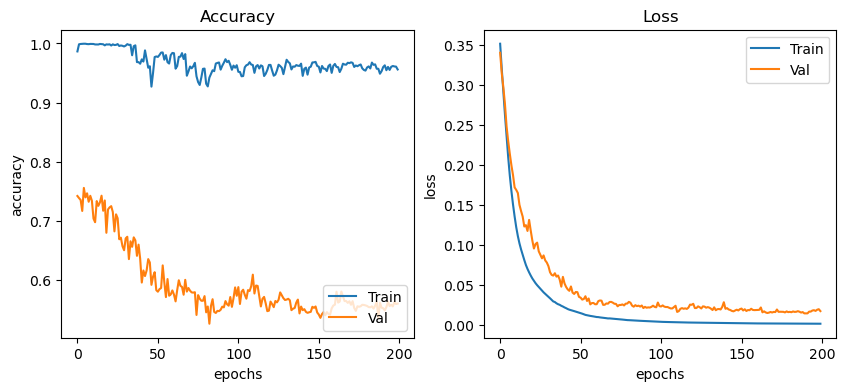

In [82]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [83]:
for x in range(10):
    print(test_data_pair[x][0], test_data_pair[x][1], test_data_label[x])

metaaug/siamese/fold1/test/nv/ISIC_0030340.jpg metaaug/siamese/fold1/test/mel/ISIC_0028897.jpg 1
metaaug/siamese/fold1/test/mel/ISIC_0033405.jpg metaaug/siamese/fold1/test/akiec/ISIC_0028941.jpg 1
metaaug/siamese/fold1/test/nv/ISIC_0029866.jpg metaaug/siamese/fold1/test/nv/ISIC_0031661.jpg 0
metaaug/siamese/fold1/test/nv/ISIC_0025334.jpg metaaug/siamese/fold1/test/nv/ISIC_0032125.jpg 0
metaaug/siamese/fold1/test/nv/ISIC_0028178.jpg metaaug/siamese/fold1/test/bkl/ISIC_0027801.jpg 1
metaaug/siamese/fold1/test/bkl/ISIC_0030758.jpg metaaug/siamese/fold1/test/bkl/ISIC_0027344.jpg 0
metaaug/siamese/fold1/test/mel/ISIC_0033524.jpg metaaug/siamese/fold1/test/bkl/ISIC_0028830.jpg 1
metaaug/siamese/fold1/test/nv/ISIC_0024661.jpg metaaug/siamese/fold1/test/nv/ISIC_0027791.jpg 0
metaaug/siamese/fold1/test/nv/ISIC_0028894.jpg metaaug/siamese/fold1/test/nv/ISIC_0029792.jpg 0
metaaug/siamese/fold1/test/nv/ISIC_0032125.jpg metaaug/siamese/fold1/test/nv/ISIC_0032515.jpg 0


In [84]:
data_root

'Datasets/1.HAM10000/metaaug/siamese/fold1/'

In [85]:
test_pairs=[]
l=sorted(glob(data_root+"set1_aug/*/*"))
for x in l:
    path=x
    lis=sorted(os.listdir(str(x)))
    for y in lis:
        d=x.split('/')[-1]
        f1=x+'/'+d+'_Original.png'
        f2=x+'/'+y
        test_pairs.append([f1,f2])

test_pairs=np.array(test_pairs)
df=pd.DataFrame(test_pairs)
df.to_csv(output_path+'test_pairs.csv', header=None, index=False)

In [86]:
%%time
pr=[]
pa=np.array(pd.read_csv(output_path+'test_pairs.csv', header=None))
for x in pa:
    im1=cv2.imread(x[0])
    im1=cv2.resize(im1, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)
    im1=np.expand_dims(im1, axis=0)
    im2=cv2.imread(x[1])
    im2=cv2.resize(im2, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)
    im2=np.expand_dims(im2, axis=0)
    pred=siamese.predict([im1,im2], verbose=0)
    pred=np.round(pred[0][0], 4)
    pr.append([x[0], x[1], pred])

pr=np.array(pr) 
df=pd.DataFrame(pr)
df.to_csv(output_path+'test_predictions.csv', header=None, index=False)

CPU times: user 1h 8min 43s, sys: 31min 45s, total: 1h 40min 28s
Wall time: 47min 44s


In [87]:
transform_list = ['AutoContrast', 'BoxBlur', 'CLAHE', 'ChannelShuffle', 'ChromaticAberration', 'CoarseDropout', 
                  'ColorJitter', 'Defocus', 'Dilation', 'ElasticTransform', 'Emboss', 'Equalize', 'EqualizeYUV', 
                  'Erosion', 'Frost', 'Gamma', 'GaussNoise', 'GaussianBlur', 'GlassBlur', 'HorizontalFlip', 
                  'HueSaturationValue', 'Invert', 'JPEGCompression', 'MedianBlur', 'MotionBlur', 'OpticalDistortion', 
                  'Original', 'Perspective', 'Posterize', 'RGBShift', 'RandomBrightnessContrast', 'RandomFog', 
                  'RandomGravel', 'RandomGridShuffle', 'RandomRain', 'RandomShadow', 'RandomSnow', 'RandomSunFlare', 
                  'RandomToneCurve', 'Rotate', 'SaltandPepper', 'Scale', 'Sharpen', 'ShearX', 'ShearY', 'ShiftScaleRotate', 
                  'Solarize', 'Speckle', 'ToGray', 'ToSepia', 'Translate', 'VerticalFlip', 'Vignette', 'ZoomBlur']

In [88]:
dt=np.array(pd.read_csv(output_path+'test_predictions.csv', header=None))
preds=dt[:,2]
preds_new=np.reshape(preds, (-1,54))

df = pd.DataFrame(preds_new, columns=transform_list)  

df.to_csv(output_path+'similarity_matrix.csv', index=False)

In [89]:
from pytz import timezone 
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time + end + "_" + savedfilename
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [90]:
print(dest)

Results/siamese/1.HAM10000/04-03-2025-08-29-17_HAM10000_Siamese_epochs_200_test_acc_75.55
